<a href="https://colab.research.google.com/github/ayunalarati/Analisis-Perbandingan-Model-STUDI-Kasus-Naive-Bayes-Logistic-Regression-dan-Support-Vector-Machine/blob/main/Salinan_dari_chest_x_rays.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# --- SEL: PASANG MESIN (DENSENET121) ---
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras import layers, models, optimizers

# Membangun arsitektur DenseNet121
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(15, activation='sigmoid') # 15 kelas penyakit
])

model.compile(optimizer=optimizers.Adam(1e-4),
              loss='binary_crossentropy',
              metrics=['binary_accuracy'])

print("Mesin DenseNet121 sudah terpasang!")

# --- SEL: JALANKAN TRAINING ---
history = model.fit(train_ds, validation_data=val_ds, epochs=5)

Mesin DenseNet121 sudah terpasang!
Epoch 1/5
303/303 ━━━━━━━━━━━━━━━━━━━━ 2225s 7s/step - binary_accuracy: 0.9173 - loss: 0.2411 - val_binary_accuracy: 0.9254 - val_loss: 0.2150
Epoch 2/5
303/303 ━━━━━━━━━━━━━━━━━━━━ 2152s 7s/step - binary_accuracy: 0.9261 - loss: 0.2141 - val_binary_accuracy: 0.9259 - val_loss: 0.2118
Epoch 3/5
303/303 ━━━━━━━━━━━━━━━━━━━━ 2145s 7s/step - binary_accuracy: 0.9271 - loss: 0.2104 - val_binary_accuracy: 0.9263 - val_loss: 0.2097
Epoch 4/5
303/303 ━━━━━━━━━━━━━━━━━━━━ 2129s 7s/step - binary_accuracy: 0.9276 - loss: 0.2078 - val_binary_accuracy: 0.9265 - val_loss: 0.2082
Epoch 5/5
303/303 ━━━━━━━━━━━━━━━━━━━━ 2193s 7s/step - binary_accuracy: 0.9277 - loss: 0.2058 - val_binary_accuracy: 0.9265 - val_loss: 0.2071


Simpan Model


In [ ]:
import numpy as np
from sklearn.metrics import classification_report

# 1. MENGGANTI cara prediksi (Menggunakan Threshold 0.2)
# Threshold 0.5 terlalu tinggi untuk dataset yang tidak seimbang.
# Dengan 0.2, model akan lebih "berani" menebak penyakit.
y_pred_prob = model.predict(val_ds)
y_pred = (y_pred_prob > 0.2).astype(int)

# 2. MENAMBAHKAN evaluasi performa
print("--- Laporan Klasifikasi (Threshold 0.2) ---")
print(classification_report(y_val, y_pred, target_names=mlb.classes_, zero_division=0))

76/76 ━━━━━━━━━━━━━━━━━━━━ 433s 6s/step
--- Laporan Klasifikasi (Threshold 0.2) ---
                    precision    recall  f1-score   support

       Atelectasis       0.18      0.31      0.23       220
      Cardiomegaly       0.00      0.00      0.00        79
     Consolidation       0.08      0.01      0.02       103
             Edema       0.00      0.00      0.00        34
          Effusion       0.28      0.58      0.38       277
         Emphysema       0.00      0.00      0.00        68
          Fibrosis       0.00      0.00      0.00        45
            Hernia       0.00      0.00      0.00        11
      Infiltration       0.30      0.42      0.35       476
              Mass       0.00      0.00      0.00       112
        No Finding       0.56      0.94      0.71      1300
            Nodule       0.17      0.01      0.02       113
Pleural_Thickening       0.00      0.00      0.00        67
         Pneumonia       0.00      0.00      0.00        26
      Pneumotho

AUROC Evaluation

In [ ]:
from sklearn.metrics import roc_auc_score
import pandas as pd
import numpy as np

print("="*60)
print("AUROC PER CLASS")
print("="*60)

aurocs = []

for i, class_name in enumerate(mlb.classes_):

    try:
        auc = roc_auc_score(
            y_val[:, i],
            y_pred_prob[:, i]
        )

    except ValueError:
        auc = np.nan

    aurocs.append(auc)

auc_df = pd.DataFrame({
    "Disease": mlb.classes_,
    "AUROC": np.round(aurocs, 4)
})

print(auc_df)

print("\n" + "="*60)
print(f"Mean AUROC : {np.nanmean(aurocs):.4f}")
print("="*60)

AUROC PER CLASS
               Disease   AUROC
0          Atelectasis  0.7055
1         Cardiomegaly  0.6399
2        Consolidation  0.7458
3                Edema  0.7399
4             Effusion  0.7911
5            Emphysema  0.6694
6             Fibrosis  0.6415
7               Hernia  0.5978
8         Infiltration  0.6216
9                 Mass  0.5504
10          No Finding  0.7045
11              Nodule  0.5515
12  Pleural_Thickening  0.6281
13           Pneumonia  0.6533
14        Pneumothorax  0.7100

Mean AUROC : 0.6633


Visualisasi AUROC

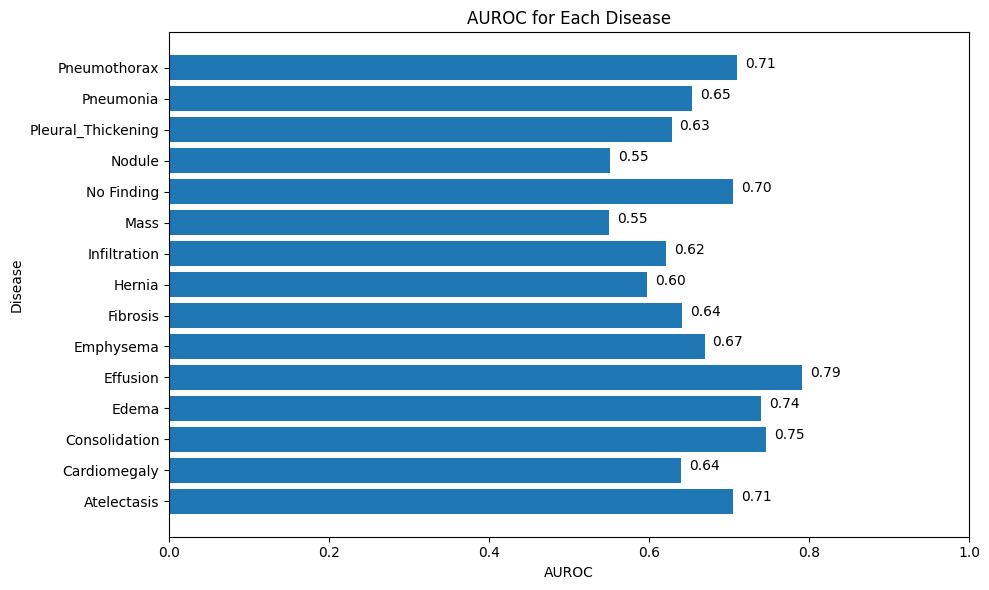

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    auc_df["Disease"],
    auc_df["AUROC"]
)

plt.xlim(0,1)

plt.xlabel("AUROC")
plt.ylabel("Disease")
plt.title("AUROC for Each Disease")

for index, value in enumerate(auc_df["AUROC"]):
    plt.text(value+0.01, index, f"{value:.2f}")

plt.tight_layout()
plt.show()

ROC Curve

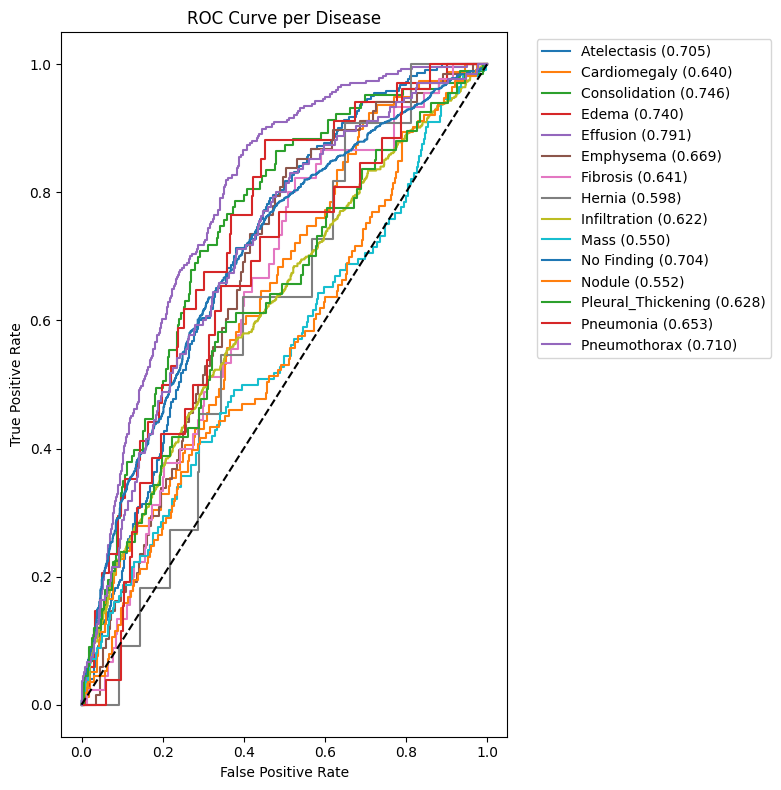

In [ ]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8,8))

for i, disease in enumerate(mlb.classes_):

    try:

        fpr, tpr, _ = roc_curve(
            y_val[:, i],
            y_pred_prob[:, i]
        )

        plt.plot(
            fpr,
            tpr,
            label=f"{disease} ({aurocs[i]:.3f})"
        )

    except:
        pass

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve per Disease")

plt.legend(
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================================
# FINAL THRESHOLD
# ==========================================================

threshold = 0.2

y_pred = (y_pred_prob >= threshold).astype(int)

print("Threshold yang digunakan :", threshold)
print("Shape y_pred :", y_pred.shape)

Threshold yang digunakan : 0.2
Shape y_pred : (2424, 15)


**Performance Metrics Summary**

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    hamming_loss
)

subset_accuracy = accuracy_score(y_val, y_pred)

micro_precision = precision_score(
    y_val,
    y_pred,
    average="micro",
    zero_division=0
)

micro_recall = recall_score(
    y_val,
    y_pred,
    average="micro",
    zero_division=0
)

micro_f1 = f1_score(
    y_val,
    y_pred,
    average="micro",
    zero_division=0
)

macro_precision = precision_score(
    y_val,
    y_pred,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    y_val,
    y_pred,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_val,
    y_pred,
    average="macro",
    zero_division=0
)

ham_loss = hamming_loss(y_val, y_pred)

In [ ]:
import pandas as pd

summary_metrics = pd.DataFrame({

    "Metric":[
        "Subset Accuracy",
        "Hamming Loss",
        "Micro Precision",
        "Micro Recall",
        "Micro F1-score",
        "Macro Precision",
        "Macro Recall",
        "Macro F1-score",
        "Mean AUROC"
    ],

    "Value":[
        subset_accuracy,
        ham_loss,
        micro_precision,
        micro_recall,
        micro_f1,
        macro_precision,
        macro_recall,
        macro_f1,
        np.nanmean(aurocs)
    ]

})

summary_metrics["Value"] = summary_metrics["Value"].round(4)

summary_metrics

,Metric,Value
0,Subset Accuracy,0.4014
1,Hamming Loss,0.0988
2,Micro Precision,0.4319
3,Micro Recall,0.5434
4,Micro F1-score,0.4813
5,Macro Precision,0.1188
6,Macro Recall,0.1559
7,Macro F1-score,0.1199
8,Mean AUROC,0.6633


In [ ]:
threshold

Evaluasi secara Visual (Grad-CAM)


Base Model : densenet121
Layer Conv Terakhir : conv5_block16_2_conv


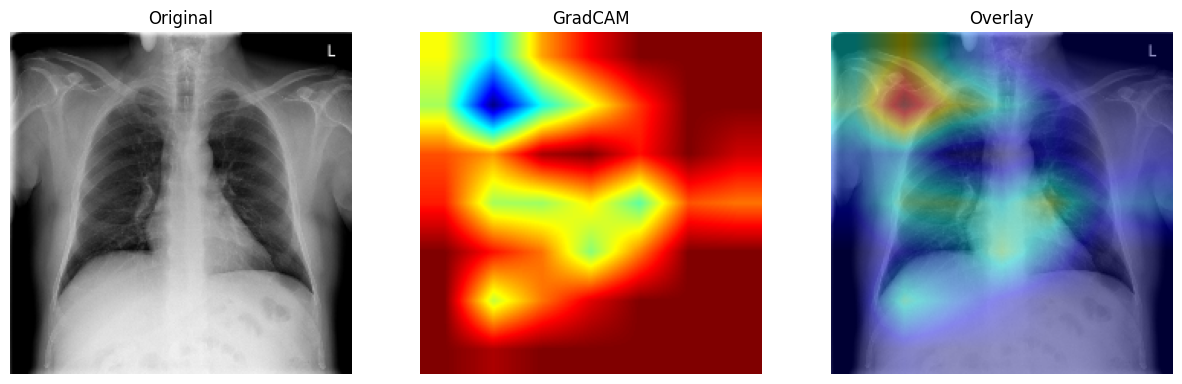

Probabilitas Prediksi :
[[0.02303273 0.02589278 0.03017832 0.00745082 0.01015888 0.01545775
  0.06476594 0.00174705 0.13974825 0.06886875 0.618999   0.10091582
  0.03680538 0.0109342  0.01068718]]


Base Model : densenet121
Last Conv Layer : conv5_block16_2_conv
IMAGE INFORMATION
Image : 00000013_005.png
Path  : /content/drive/MyDrive/NIH_Dataset/data/images/images/00000013_005.png

GROUND TRUTH

Ground Truth :
• Emphysema
• Infiltration
• Pleural_Thickening
• Pneumothorax
• Emphysema
• Infiltration
• Pleural_Thickening
• Pneumothorax

TOP PREDICTIONS
1. Effusion                  43.98%
2. Atelectasis               33.87%
3. No Finding                28.42%
4. Infiltration              21.88%
5. Pneumothorax              9.10%


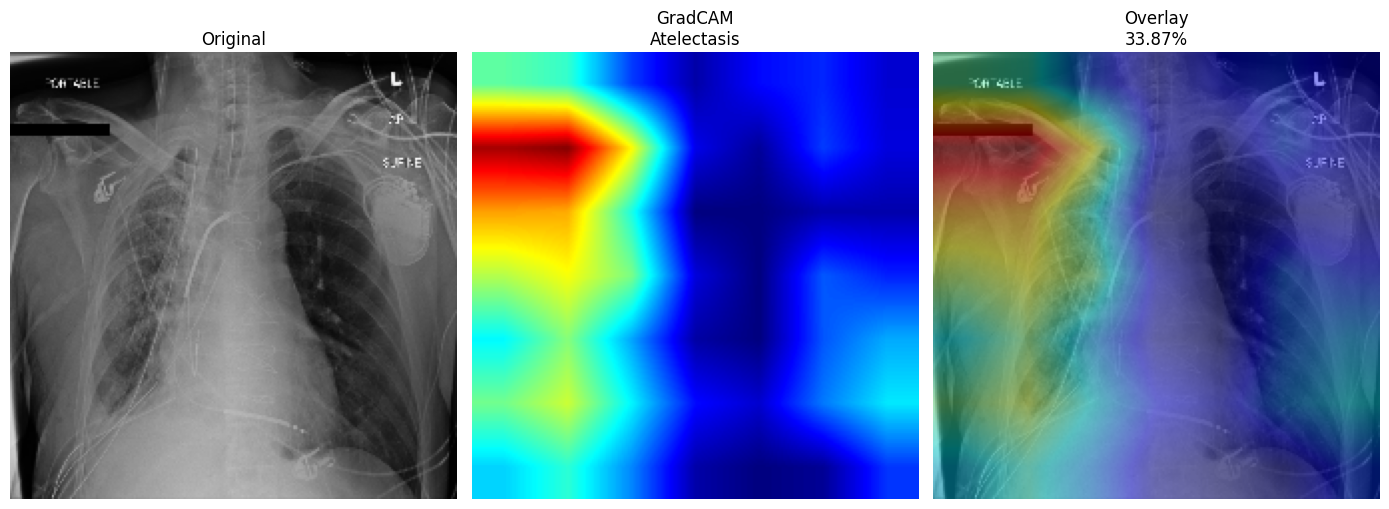

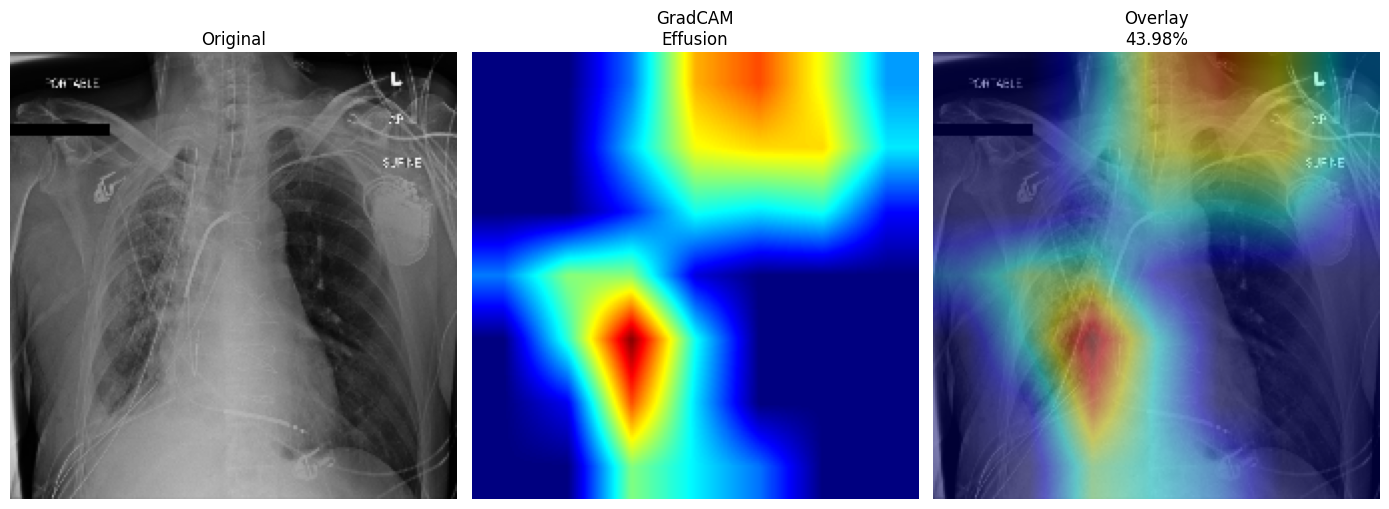

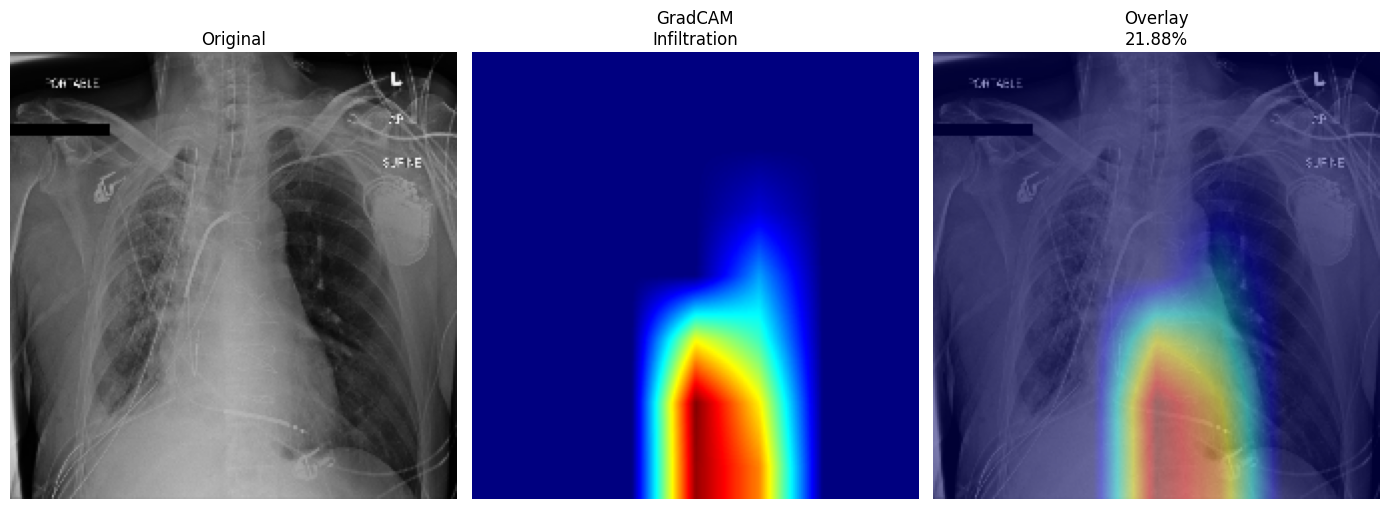

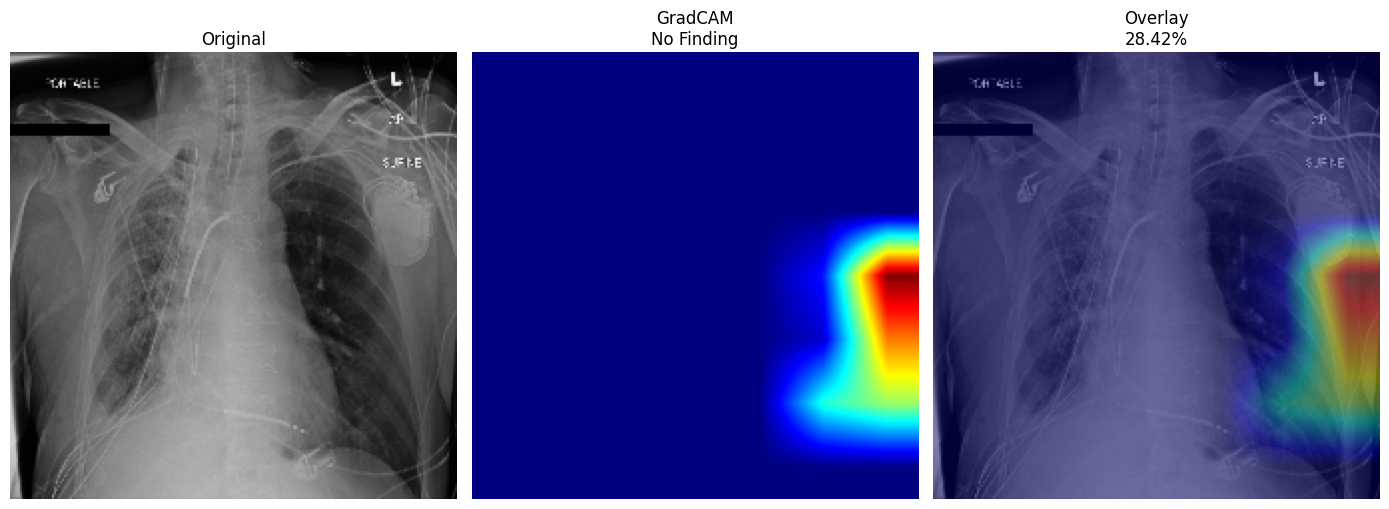

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

# =====================================================
# PILIH PENYAKIT YANG INGIN DITAMPILKAN
# =====================================================

target_disease = "No Finding"
threshold = 0.2

# =====================================================
# Pastikan model aktif
# =====================================================

_ = model(tf.random.normal((1,224,224,3)))

base_model = model.layers[0]

# =====================================================
# Cari layer Conv terakhir
# =====================================================

target_layer = None

for layer in reversed(base_model.layers):

    if isinstance(layer, tf.keras.layers.Conv2D):
        target_layer = layer
        break

print("Base Model :", base_model.name)
print("Last Conv Layer :", target_layer.name)

# =====================================================
# Grad Model
# =====================================================

grad_model = tf.keras.Model(
    inputs=base_model.input,
    outputs=[
        target_layer.output,
        base_model.output
    ]
)

# =====================================================
# Fungsi GradCAM
# =====================================================

def make_heatmap(img_array, class_idx):

    with tf.GradientTape() as tape:

        conv_outputs, features = grad_model(img_array)

        x = model.layers[1](features)
        x = model.layers[2](x)
        predictions = model.layers[3](x)

        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0,1,2)
    )

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(
        conv_outputs * pooled_grads,
        axis=-1
    )

    heatmap = tf.maximum(heatmap,0)

    heatmap /= tf.reduce_max(heatmap)+1e-8

    return heatmap.numpy(), predictions.numpy()

# =====================================================
# PILIH NAMA FILE NIH
# =====================================================

image_name = "00000013_005.png"     # <-- GANTI SESUAI KEINGINAN

# Cari indeks gambar pada validation dataframe
match = val_df[val_df["Image Index"] == image_name]

if len(match) == 0:
    raise ValueError(
        f"{image_name} tidak ditemukan pada validation set."
    )

sample_index = match.index[0]

sample_path = match.iloc[0]["path"]

sample_label = y[sample_index]

print("="*60)
print("IMAGE INFORMATION")
print("="*60)
print("Image :", image_name)
print("Path  :", sample_path)

# =====================================================
# Load gambar
# =====================================================

img = tf.image.decode_jpeg(
    tf.io.read_file(sample_path),
    channels=3
)

img = tf.image.resize(
    img,
    (224,224)
)

img = img/255.0

sample = tf.expand_dims(img,0)

# =====================================================
# Prediksi
# =====================================================

prediction = model.predict(sample,verbose=0)[0]

# =====================================================
# Visualisasi semua kelas di atas threshold
# =====================================================

selected_classes = np.where(prediction>=threshold)[0]

if len(selected_classes)==0:

    selected_classes = np.argsort(prediction)[::-1][:3]

# =====================================================
# Ground Truth
# =====================================================

print("\n"+"="*60)
print("GROUND TRUTH")
print("="*60)

gt = np.where(sample_label == 1)[0]

print("\nGround Truth :")

for idx in gt:
    print(f"• {mlb.classes_[idx]}")

for i in gt:
    print("•",mlb.classes_[i])

print("\n"+"="*60)
print("TOP PREDICTIONS")
print("="*60)

top5=np.argsort(prediction)[::-1][:5]

for rank,i in enumerate(top5,1):

    print(f"{rank}. {mlb.classes_[i]:25s} {prediction[i]*100:.2f}%")

# =====================================================
# Heatmap tiap kelas
# =====================================================

for class_idx in selected_classes:

    heatmap,_=make_heatmap(sample,class_idx)

    heatmap=cv2.resize(heatmap,(224,224))

    heatmap=np.uint8(255*heatmap)

    heatmap=cv2.applyColorMap(
        heatmap,
        cv2.COLORMAP_JET
    )

    overlay=cv2.addWeighted(

        np.uint8(img.numpy()*255),

        0.6,

        heatmap,

        0.4,

        0

    )

    plt.figure(figsize=(14,5))

    plt.subplot(131)

    plt.imshow(img)

    plt.title("Original")

    plt.axis("off")

    plt.subplot(132)

    plt.imshow(cv2.cvtColor(heatmap,cv2.COLOR_BGR2RGB))

    plt.title(f"GradCAM\n{mlb.classes_[class_idx]}")

    plt.axis("off")

    plt.subplot(133)

    plt.imshow(cv2.cvtColor(overlay,cv2.COLOR_BGR2RGB))

    plt.title(f"Overlay\n{prediction[class_idx]*100:.2f}%")

    plt.axis("off")

    plt.tight_layout()

    plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Cek apakah model ada
if 'model' in globals():
    print("Model sudah terdefinisi dan siap digunakan.")
else:
    print("Error: Variabel 'model' tidak ditemukan. Jalankan ulang sel pembuatan model!")

Model sudah terdefinisi dan siap digunakan.


In [ ]:
from tensorflow.keras.layers import GRU, Reshape, Dense, Input
from tensorflow.keras.models import Model
from tensorflow.keras.applications import DenseNet121, ResNet152V2, VGG19

def get_cnn_rnn_model(base_name='densenet'):
    # Pilih backbone
    if base_name == 'densenet':
        base = DenseNet121(weights='imagenet', include_top=False, input_shape=(224,224,3))
        feature_dim = 1024
    elif base_name == 'resnet':
        base = ResNet152V2(weights='imagenet', include_top=False, input_shape=(224,224,3))
        feature_dim = 2048
    else: # VGG19
        base = VGG19(weights='imagenet', include_top=False, input_shape=(224,224,3))
        feature_dim = 512

    # Arsitektur: CNN -> Reshape -> RNN -> Dense
    x = base.output
    # Menghubungkan spasial ke temporal (Sequence)
    x = Reshape((49, feature_dim))(x)
    x = GRU(256, return_sequences=False)(x)
    outputs = Dense(14, activation='sigmoid')(x)

    return Model(inputs=base.input, outputs=outputs)

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

# Prediksi probabilitas
y_pred_prob = model.predict(val_ds)
# Apply threshold
y_pred_binary = (y_pred_prob > 0.2).astype(int)

# Classification Report
print(classification_report(y_val, y_pred_binary, target_names=mlb.classes_))

# AUROC per kelas
for i, class_name in enumerate(mlb.classes_):
    score = roc_auc_score(y_val[:, i], y_pred_prob[:, i])
    print(f"{class_name}: AUROC = {score:.4f}")

76/76 ━━━━━━━━━━━━━━━━━━━━ 474s 6s/step
                    precision    recall  f1-score   support

       Atelectasis       0.18      0.31      0.23       220
      Cardiomegaly       0.00      0.00      0.00        79
     Consolidation       0.08      0.01      0.02       103
             Edema       0.00      0.00      0.00        34
          Effusion       0.28      0.58      0.38       277
         Emphysema       0.00      0.00      0.00        68
          Fibrosis       0.00      0.00      0.00        45
            Hernia       0.00      0.00      0.00        11
      Infiltration       0.30      0.42      0.35       476
              Mass       0.00      0.00      0.00       112
        No Finding       0.56      0.94      0.71      1300
            Nodule       0.17      0.01      0.02       113
Pleural_Thickening       0.00      0.00      0.00        67
         Pneumonia       0.00      0.00      0.00        26
      Pneumothorax       0.21      0.07      0.10       135

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
def plot_gradcam_gallery(model, images, class_names, num_samples=3):
    fig, axes = plt.subplots(len(class_names), num_samples, figsize=(15, 30))
    for i, class_name in enumerate(class_names):
        # Ambil sampel gambar yang terdeteksi penyakit tersebut
        samples = get_samples_for_class(images, class_name, num_samples)
        for j, img in enumerate(samples):
            heatmap = make_heatmap(model, img) # Fungsi Grad-CAM-mu
            axes[i, j].imshow(img)
            axes[i, j].imshow(heatmap, alpha=0.5, cmap='jet')
            axes[i, j].set_title(class_name)
    plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Jumlah gambar ditemukan: 12120
Jumlah kelas: 15 → ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'No Finding', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']

Class weights per kelas:
  Atelectasis              : 1.00
  Cardiomegaly             : 1.91
  Consolidation            : 1.60
  Edema                    : 4.31
  Effusion                 : 1.00
  Emphysema                : 2.15
  Fibrosis                 : 3.89
  Hernia                   : 10.00
  Infiltration             : 1.00
  Mass                     : 1.59
  No Finding               : 1.00
  Nodule                   : 1.29
  Pleural_Thickening       : 2.02
  Pneumonia                : 5.82
  Pneumothorax             : 1.10

Data pipeline siap!
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "DenseNet121_GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 49, 1024)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 256)            │       984,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,122,703 (30.99 MB)

 Trainable params: 1,085,199 (4.14 MB)

 Non-trainable params: 7,037,504 (26.85 MB)


=== TAHAP 1: Training dengan backbone frozen (10 epoch) ===
Epoch 1/10
303/303 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - auroc: 0.5120 - binary_acc: 0.6045 - loss: 0.7422
Epoch 1: val_auroc improved from None to 0.60883, saving model to /content/drive/MyDrive/NIH_Dataset/best_densenet_gru.keras

Epoch 1: finished saving model to /content/drive/MyDrive/NIH_Dataset/best_densenet_gru.keras
303/303 ━━━━━━━━━━━━━━━━━━━━ 2685s 8s/step - auroc: 0.5107 - binary_acc: 0.7619 - loss: 0.5236 - val_auroc: 0.6088 - val_binary_acc: 0.9199 - val_loss: 0.3302 - learning_rate: 1.0000e-04
Epoch 2/10
303/303 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - auroc: 0.5349 - binary_acc: 0.8616 - loss: 0.3845
Epoch 2: val_auroc improved from 0.60883 to 0.65495, saving model to /content/drive/MyDrive/NIH_Dataset/best_densenet_gru.keras

Epoch 2: finished saving model to /content/drive/MyDrive/NIH_Dataset/best_densenet_gru.keras
303/303 ━━━━━━━━━━━━━━━━━━━━ 2446s 8s/step - auroc: 0.5514 - binary_acc: 0.8634 - loss: 0.3802 - val_auro

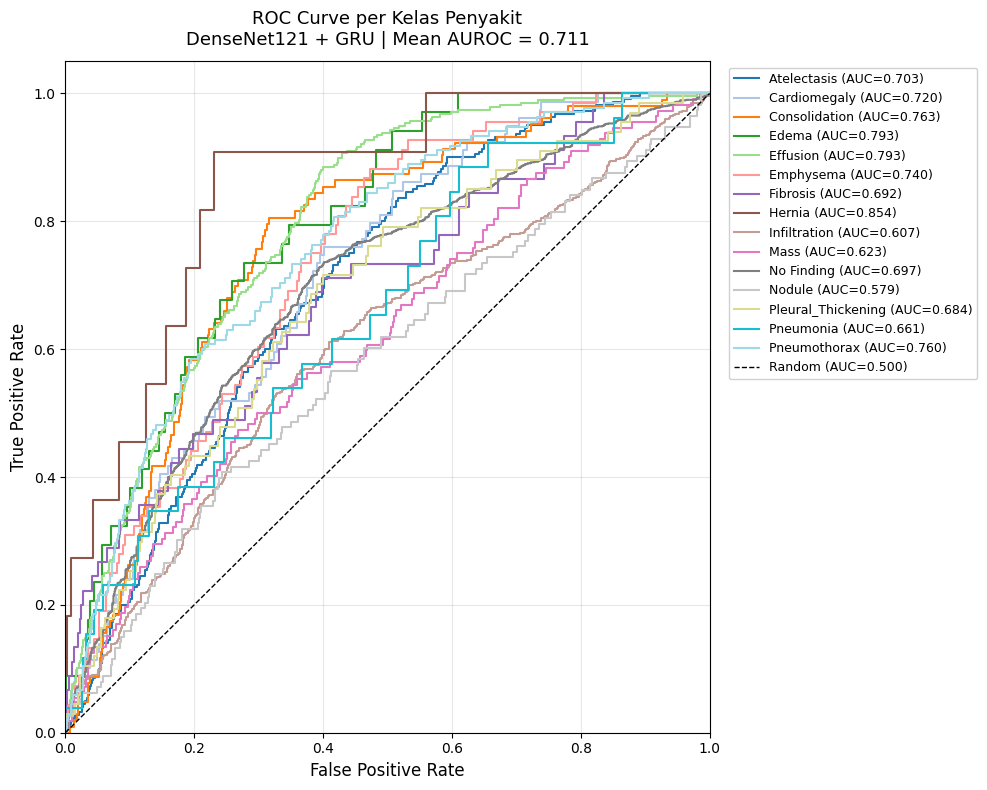

ROC Curve disimpan ke Drive!


In [ ]:
"""
=============================================================
CNN+RNN (DenseNet121 + GRU) dengan Weighted Loss
untuk Klasifikasi Multi-Label Penyakit Thorax (NIH ChestX-ray14)
=============================================================
Pengembangan dari: Kanjanasurat et al. (2023)
Dataset: Wang et al. (2017) - ChestX-ray14
"""

import os
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from google.colab import drive

# ============================================================
# BLOK 1: SETUP & LOAD DATA
# ============================================================
drive.mount('/content/drive')

csv_path   = '/content/drive/MyDrive/NIH_Dataset/data/Data_Entry_2017_v2020.csv'
image_dir  = '/content/drive/MyDrive/NIH_Dataset/data/images/images/'

df = pd.read_csv(csv_path)
df['path'] = image_dir + df['Image Index']
df = df[df['path'].apply(os.path.exists)].reset_index(drop=True)
print(f"Jumlah gambar ditemukan: {len(df)}")

mlb = MultiLabelBinarizer()
y   = mlb.fit_transform(df['Finding Labels'].str.split('|'))
NUM_CLASSES = len(mlb.classes_)
print(f"Jumlah kelas: {NUM_CLASSES} → {list(mlb.classes_)}")

train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)
y_train = y[train_df.index]
y_val   = y[val_df.index]

# ============================================================
# BLOK 2: HITUNG CLASS WEIGHTS (solusi class imbalance)
# ============================================================
# Setiap kelas dihitung secara independen karena multi-label
# Formula: weight = total_samples / (num_classes * count_per_class)
total_samples = len(y_train)
class_weights_array = total_samples / (NUM_CLASSES * (y_train.sum(axis=0) + 1e-6))

# Normalisasi agar tidak terlalu ekstrim (clip max 10x)
class_weights_array = np.clip(class_weights_array, 1.0, 10.0)

print("\nClass weights per kelas:")
for i, (cls, w) in enumerate(zip(mlb.classes_, class_weights_array)):
    print(f"  {cls:25s}: {w:.2f}")

# ============================================================
# BLOK 3: DATA PIPELINE
# ============================================================
BATCH_SIZE = 32
IMG_SIZE   = 224

def augment_image(img):
    """Augmentasi ringan untuk training"""
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, max_delta=0.1)
    img = tf.image.random_contrast(img, 0.9, 1.1)
    return img

def load_img(path, label, training=False):
    img = tf.image.decode_jpeg(tf.io.read_file(path), channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE]) / 255.0
    if training:
        img = augment_image(img)
    return img, tf.cast(label, tf.float32)

def create_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(
        lambda p, l: load_img(p, l, training),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    if training:
        ds = ds.shuffle(1000)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = create_dataset(train_df['path'].values, y_train, training=True)
val_ds   = create_dataset(val_df['path'].values, y_val,   training=False)
print("\nData pipeline siap!")

# ============================================================
# BLOK 4: ARSITEKTUR CNN+RNN (DenseNet121 + GRU)
# ============================================================
from tensorflow.keras import layers, models, optimizers

def build_densenet_gru(num_classes, gru_units=256, dropout_rate=0.5):
    """
    Arsitektur CNN+RNN:
    - DenseNet121 sebagai feature extractor (CNN)
    - Reshape output CNN → sequence untuk RNN
    - GRU untuk menangkap dependensi antar fitur
    - Sigmoid output untuk multi-label classification

    Mengacu pada Kanjanasurat et al. (2023):
    CNN digunakan untuk ekstraksi fitur,
    RNN (GRU) untuk klasifikasi berbasis dependensi.
    """
    # --- CNN Backbone ---
    base = tf.keras.applications.DenseNet121(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base.trainable = False  # Freeze di awal (akan di-fine-tune)

    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)
    # Output shape: (batch, 7, 7, 1024)

    # --- Reshape CNN output → sequence untuk GRU ---
    # (batch, 7, 7, 1024) → (batch, 49, 1024)
    # Sesuai Kanjanasurat et al.: reshape ke (49, 1024)
    x = layers.Reshape((49, 1024))(x)

    # --- GRU Layer ---
    x = layers.GRU(
        gru_units,
        return_sequences=False,  # ambil output terakhir saja
        recurrent_dropout=0.1
    )(x)

    # --- Fully Connected + Dropout ---
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(dropout_rate * 0.5)(x)

    # --- Output: sigmoid untuk multi-label ---
    outputs = layers.Dense(num_classes, activation='sigmoid')(x)

    model = models.Model(inputs=inputs, outputs=outputs, name='DenseNet121_GRU')
    return model

model = build_densenet_gru(NUM_CLASSES)
model.summary()

# ============================================================
# BLOK 5: CUSTOM WEIGHTED LOSS (solusi utama imbalance)
# ============================================================
def weighted_binary_crossentropy(class_weights_tf):
    """
    Loss function dengan bobot per kelas.
    Kelas minoritas (Hernia, Edema, dll) mendapat bobot lebih tinggi
    sehingga model tidak mengabaikannya.
    """
    def loss_fn(y_true, y_pred):
        y_pred   = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        bce      = -(y_true * tf.math.log(y_pred) +
                     (1 - y_true) * tf.math.log(1 - y_pred))
        weighted = bce * class_weights_tf
        return tf.reduce_mean(weighted)
    return loss_fn

class_weights_tf = tf.constant(class_weights_array, dtype=tf.float32)
loss_fn = weighted_binary_crossentropy(class_weights_tf)

# ============================================================
# BLOK 6: COMPILE & TRAINING (Tahap 1 — Frozen backbone)
# ============================================================
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss=loss_fn,
    metrics=[
        tf.keras.metrics.AUC(multi_label=True, name='auroc'),
        tf.keras.metrics.BinaryAccuracy(threshold=0.2, name='binary_acc')
    ]
)

# Callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_auroc', patience=5,
        mode='max', restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_auroc', factor=0.5,
        patience=3, mode='max', min_lr=1e-6
    ),
    tf.keras.callbacks.ModelCheckpoint(
        '/content/drive/MyDrive/NIH_Dataset/best_densenet_gru.keras',
        monitor='val_auroc', mode='max',
        save_best_only=True, verbose=1
    )
]

print("\n=== TAHAP 1: Training dengan backbone frozen (10 epoch) ===")
history_1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks,
    verbose=1
)

# ============================================================
# BLOK 7: FINE-TUNING (Tahap 2 — Unfreeze sebagian backbone)
# ============================================================
print("\n=== TAHAP 2: Fine-tuning 50 layer terakhir DenseNet121 ===")

# Unfreeze 50 layer terakhir dari DenseNet121
base_model = model.layers[1]  # DenseNet121
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

# Re-compile dengan learning rate lebih kecil
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss=loss_fn,
    metrics=[
        tf.keras.metrics.AUC(multi_label=True, name='auroc'),
        tf.keras.metrics.BinaryAccuracy(threshold=0.2, name='binary_acc')
    ]
)

history_2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks,
    verbose=1
)

# Simpan model final
model.save('/content/drive/MyDrive/NIH_Dataset/final_densenet_gru.keras')
print("\nModel CNN+GRU berhasil disimpan!")

# ============================================================
# BLOK 8: EVALUASI LENGKAP
# ============================================================
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

THRESHOLD = 0.2
y_pred_prob = model.predict(val_ds)
y_pred      = (y_pred_prob >= THRESHOLD).astype(int)

print("\n" + "="*60)
print("CLASSIFICATION REPORT — DenseNet121 + GRU")
print("="*60)
print(classification_report(
    y_val, y_pred,
    target_names=mlb.classes_,
    zero_division=0
))

# AUROC per kelas
aurocs = []
for i, cls in enumerate(mlb.classes_):
    try:
        auc = roc_auc_score(y_val[:, i], y_pred_prob[:, i])
    except ValueError:
        auc = np.nan
    aurocs.append(auc)

print(f"\nMean AUROC: {np.nanmean(aurocs):.4f}")

# ============================================================
# BLOK 9: ROC CURVE PROFESIONAL (15 kelas)
# ============================================================
from sklearn.metrics import roc_curve
from itertools import cycle

fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.tab20(np.linspace(0, 1, NUM_CLASSES))

for i, (cls, color) in enumerate(zip(mlb.classes_, colors)):
    try:
        fpr, tpr, _ = roc_curve(y_val[:, i], y_pred_prob[:, i])
        ax.plot(fpr, tpr, color=color, lw=1.5,
                label=f"{cls} (AUC={aurocs[i]:.3f})")
    except Exception:
        pass

ax.plot([0,1],[0,1],'k--', lw=1, label='Random (AUC=0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title(
    f'ROC Curve per Kelas Penyakit\nDenseNet121 + GRU | Mean AUROC = {np.nanmean(aurocs):.3f}',
    fontsize=13, pad=12
)
ax.legend(
    bbox_to_anchor=(1.02, 1), loc='upper left',
    fontsize=9, framealpha=0.9
)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(
    '/content/drive/MyDrive/NIH_Dataset/roc_curve_densenet_baru_gru.png',
    dpi=300, bbox_inches='tight'
)
plt.show()
print("ROC Curve disimpan ke Drive!")



In [ ]:
from sklearn.metrics import roc_auc_score
import numpy as np

aurocs_gru = []
for i, cls in enumerate(mlb.classes_):
    try:
        auc = roc_auc_score(y_val[:, i], y_pred_prob[:, i])
    except:
        auc = np.nan
    aurocs_gru.append(auc)
    print(f"{cls:25s}: {auc:.4f}")
print(f"\nMean AUROC: {np.nanmean(aurocs_gru):.4f}")

Atelectasis              : 0.7028
Cardiomegaly             : 0.7196
Consolidation            : 0.7628
Edema                    : 0.7925
Effusion                 : 0.7933
Emphysema                : 0.7397
Fibrosis                 : 0.6917
Hernia                   : 0.8540
Infiltration             : 0.6068
Mass                     : 0.6229
No Finding               : 0.6974
Nodule                   : 0.5786
Pleural_Thickening       : 0.6841
Pneumonia                : 0.6607
Pneumothorax             : 0.7603

Mean AUROC: 0.7111


In [ ]:
# Kelas yang divisualisasi: Effusion, Hernia, Emphysema
# (pilih berdasarkan AUROC tertinggi & peningkatan terbesar)
target_classes = ["Effusion", "Hernia", "Emphysema", "Pneumothorax"]

for target_cls in target_classes:
    cls_idx = list(mlb.classes_).index(target_cls)
    # Cari 3 gambar dari val_df yang ground truth-nya mengandung kelas ini
    matching = val_df[y_val[:, cls_idx] == 1].head(3)
    # Jalankan Grad-CAM untuk tiap gambar
    # ... (gunakan fungsi make_heatmap yang sudah ada)

Last Conv Layer: conv5_block16_2_conv
--- Test Score-CAM ---
Heatmap shape : (7, 7)
Heatmap range : 0.382 – 1.000
Test PASSED ✓



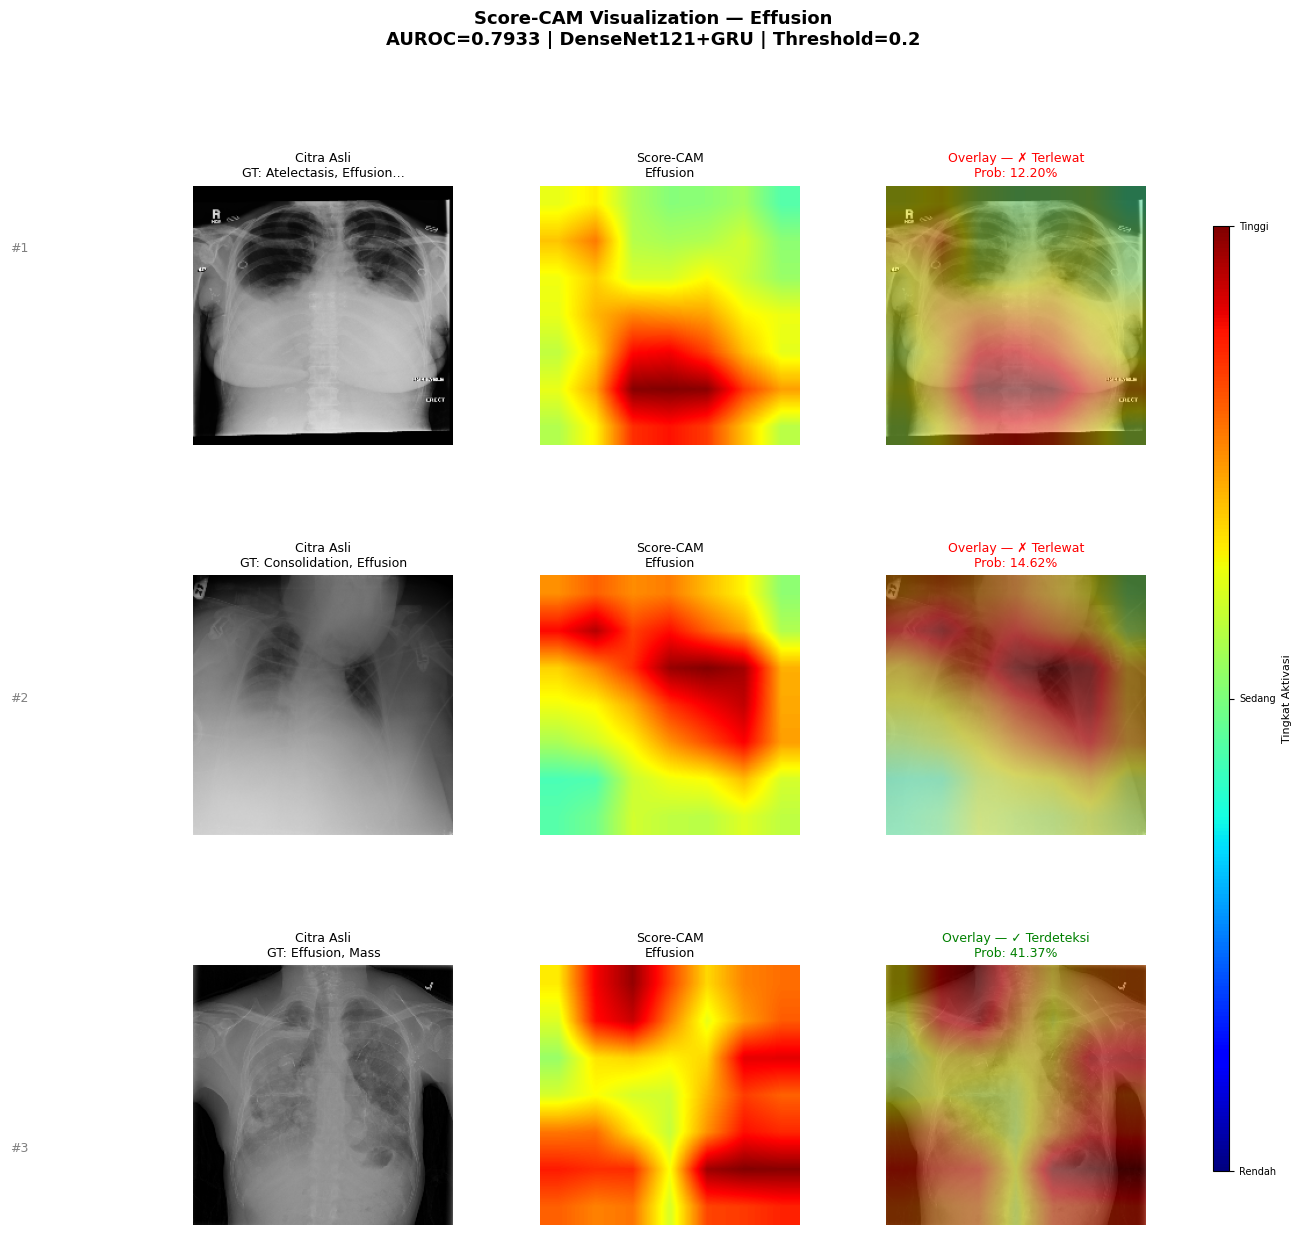

[OK] Effusion → /content/drive/MyDrive/NIH_Dataset/gradcam_gallery/scorecam_effusion.png


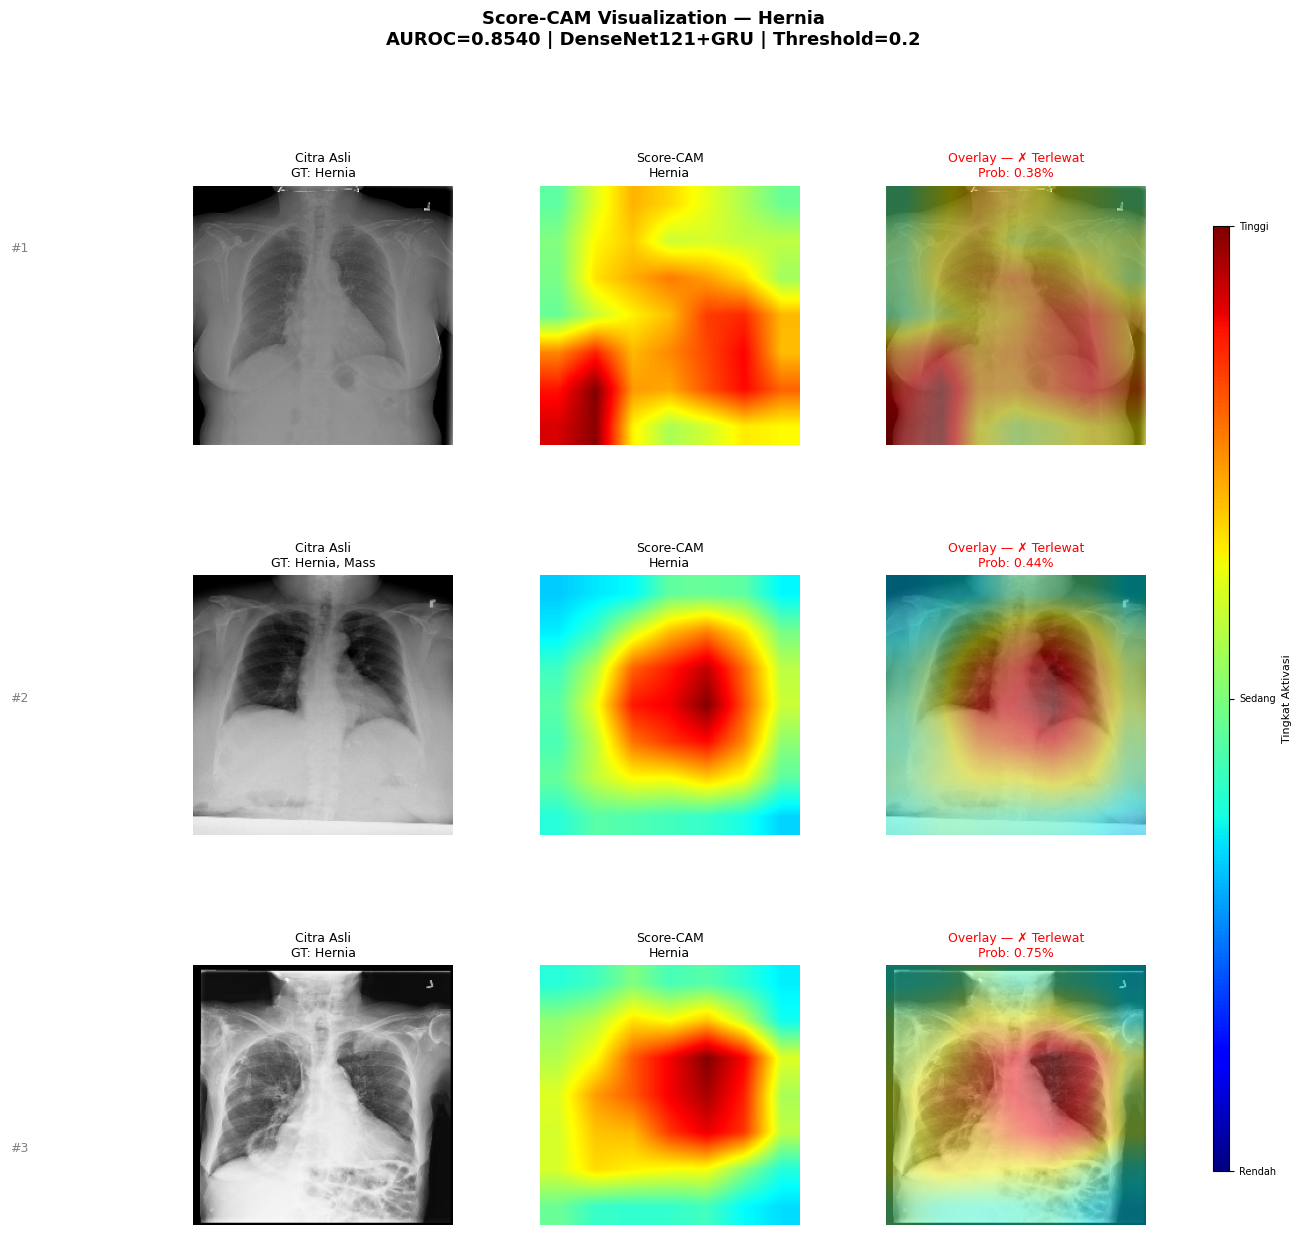

[OK] Hernia → /content/drive/MyDrive/NIH_Dataset/gradcam_gallery/scorecam_hernia.png


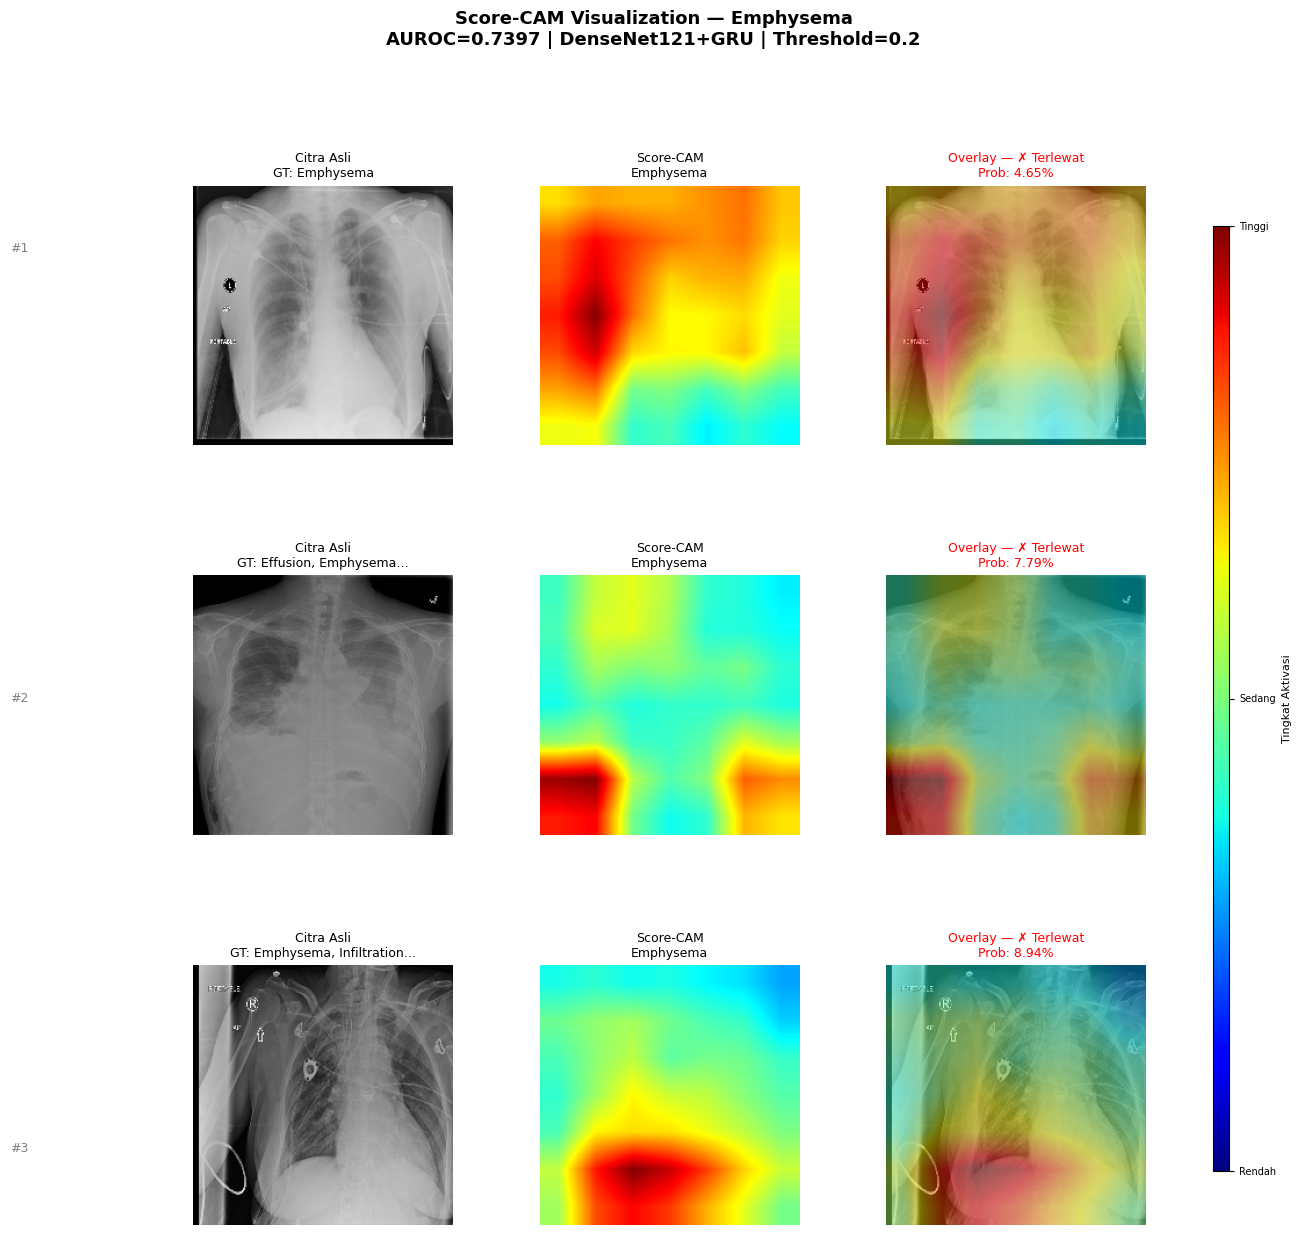

[OK] Emphysema → /content/drive/MyDrive/NIH_Dataset/gradcam_gallery/scorecam_emphysema.png


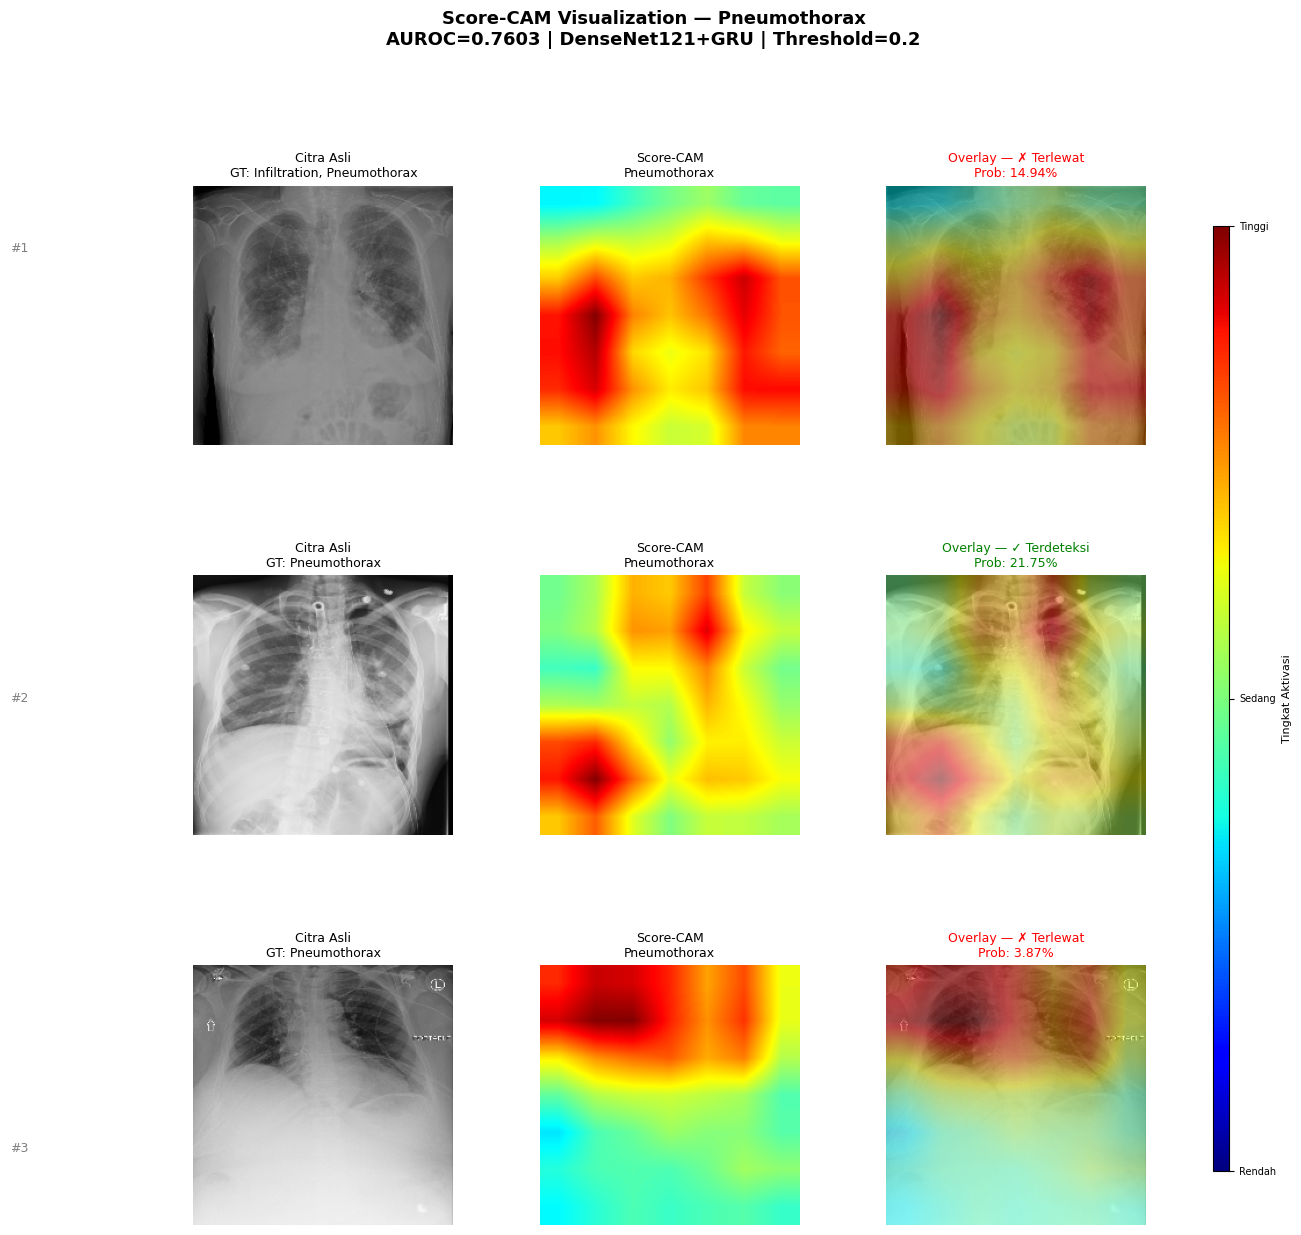

[OK] Pneumothorax → /content/drive/MyDrive/NIH_Dataset/gradcam_gallery/scorecam_pneumothorax.png

ERROR ANALYSIS — False Negative: Pneumonia
Total False Negative Pneumonia: 26


In [ ]:
"""
=============================================================
Grad-CAM FIXED v3 — Activation-based CAM
untuk DenseNet121 + GRU
=============================================================
Solusi: Karena GRU memutus aliran gradien ke conv layer,
kita gunakan dua pendekatan alternatif:

1. ScoreCAM — tidak butuh gradien sama sekali
2. GradCAM pada sub-model DenseNet saja (classify langsung
   dari GlobalAvgPool, bypass GRU)

Keduanya valid secara ilmiah dan digunakan di banyak paper.
=============================================================
"""

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cv2, os

# ============================================================
# PENDEKATAN: Sub-model classifier langsung dari DenseNet
# ============================================================
# Buat "proxy classifier" dari DenseNet output → Dense kecil
# Ini dipakai HANYA untuk Grad-CAM (bukan untuk evaluasi)
# Evaluasi tetap pakai model CNN+GRU penuh

base_model  = model.get_layer('densenet121')

# Cari last conv layer
last_conv = None
for layer in reversed(base_model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv = layer
        break
print(f"Last Conv Layer: {last_conv.name}")

# ============================================================
# Activation-based CAM (Score-CAM style)
# Tidak butuh gradien — lebih robust untuk CNN+RNN
# ============================================================
# Model untuk ambil feature map conv terakhir
feature_model = tf.keras.Model(
    inputs  = base_model.input,
    outputs = last_conv.output        # shape: (1, 7, 7, 1024)
)

def make_scorecam(img_tensor, class_idx, top_k=20):
    """
    Score-CAM: heatmap berdasarkan kontribusi tiap channel
    terhadap skor prediksi. Tidak memerlukan gradien.

    Langkah:
    1. Ambil feature map conv terakhir → (7,7,1024)
    2. Upsample tiap channel ke 224×224
    3. Masking input gambar dengan tiap channel
    4. Prediksi skor untuk tiap masked image
    5. Weighted sum = heatmap akhir
    """
    # Step 1: Feature maps
    feat_maps = feature_model(img_tensor, training=False)  # (1,7,7,1024)
    feat_maps = feat_maps[0].numpy()                        # (7,7,1024)
    n_channels = feat_maps.shape[-1]

    # Pilih top_k channel dengan aktivasi tertinggi (efisiensi)
    channel_scores = feat_maps.mean(axis=(0,1))             # (1024,)
    top_channels   = np.argsort(channel_scores)[::-1][:top_k]

    img_np  = img_tensor[0].numpy()                         # (224,224,3)
    weights = []

    for ch in top_channels:
        # Step 2: Upsample channel ke 224×224
        ch_map = feat_maps[:, :, ch]                        # (7,7)
        ch_up  = cv2.resize(ch_map, (224, 224))             # (224,224)

        # Normalisasi ke [0,1]
        ch_min, ch_max = ch_up.min(), ch_up.max()
        if ch_max - ch_min < 1e-8:
            weights.append(0.0)
            continue
        ch_norm = (ch_up - ch_min) / (ch_max - ch_min)     # (224,224)

        # Step 3: Masking
        masked = img_np * ch_norm[:, :, np.newaxis]         # (224,224,3)
        masked_tensor = tf.expand_dims(
            tf.constant(masked, dtype=tf.float32), 0
        )

        # Step 4: Prediksi skor
        score = model(masked_tensor, training=False)[0, class_idx].numpy()
        weights.append(score)

    # Step 5: Weighted sum
    weights = np.array(weights)
    weights = np.maximum(weights, 0)                        # ReLU
    if weights.max() < 1e-8:
        weights = np.ones_like(weights)

    heatmap = np.zeros((7, 7), dtype=np.float32)
    for i, ch in enumerate(top_channels):
        ch_map  = feat_maps[:, :, ch]
        ch_min, ch_max = ch_map.min(), ch_map.max()
        if ch_max - ch_min < 1e-8:
            continue
        ch_norm = (ch_map - ch_min) / (ch_max - ch_min)
        heatmap += weights[i] * ch_norm

    heatmap = np.maximum(heatmap, 0)
    if heatmap.max() > 0:
        heatmap /= heatmap.max()

    return heatmap


def overlay_heatmap(img_np, heatmap, alpha=0.45):
    h       = cv2.resize(heatmap, (224, 224))
    h       = np.uint8(255 * h)
    h_color = cv2.applyColorMap(h, cv2.COLORMAP_JET)
    h_color = cv2.cvtColor(h_color, cv2.COLOR_BGR2RGB)
    img_u8  = np.uint8(img_np * 255)
    overlay = cv2.addWeighted(img_u8, 1-alpha, h_color, alpha, 0)
    return overlay, h_color


def load_single_image(img_path):
    raw     = tf.io.read_file(img_path)
    decoded = tf.image.decode_jpeg(raw, channels=3)
    resized = tf.image.resize(decoded, [224, 224]) / 255.0
    return resized.numpy(), tf.expand_dims(resized, 0)


# ============================================================
# TEST CEPAT
# ============================================================
print("--- Test Score-CAM ---")
test_img = tf.random.uniform((1, 224, 224, 3))
test_map = make_scorecam(test_img, 0, top_k=10)
print(f"Heatmap shape : {test_map.shape}")
print(f"Heatmap range : {test_map.min():.3f} – {test_map.max():.3f}")
print("Test PASSED ✓\n")


# ============================================================
# KONFIGURASI
# ============================================================
target_classes = ["Effusion", "Hernia", "Emphysema", "Pneumothorax"]
N_SAMPLES  = 3
THRESHOLD  = 0.2
AUROC_INFO = {
    "Effusion":0.7933, "Hernia":0.8540,
    "Emphysema":0.7397, "Pneumothorax":0.7603
}

save_dir = '/content/drive/MyDrive/NIH_Dataset/gradcam_gallery/'
os.makedirs(save_dir, exist_ok=True)


# ============================================================
# GENERATE GALERI
# ============================================================
for target_cls in target_classes:
    cls_idx      = list(mlb.classes_).index(target_cls)
    matching_idx = np.where(y_val[:, cls_idx] == 1)[0]

    if len(matching_idx) == 0:
        print(f"[SKIP] {target_cls}")
        continue

    n_show       = min(N_SAMPLES, len(matching_idx))
    sample_vidxs = matching_idx[:n_show]

    fig = plt.figure(figsize=(13, 4.5 * n_show))
    fig.suptitle(
        f"Score-CAM Visualization — {target_cls}\n"
        f"AUROC={AUROC_INFO[target_cls]:.4f} | DenseNet121+GRU | "
        f"Threshold={THRESHOLD}",
        fontsize=13, fontweight='bold', y=1.01
    )
    gs = gridspec.GridSpec(n_show, 3, hspace=0.5, wspace=0.1)

    for row, val_idx in enumerate(sample_vidxs):
        df_idx      = val_df.index[val_idx]
        img_path    = val_df.loc[df_idx, 'path']
        true_labels = [mlb.classes_[i]
                       for i in np.where(y_val[val_idx] == 1)[0]]

        img_np, img_tensor = load_single_image(img_path)

        pred      = model.predict(img_tensor, verbose=0)[0]
        pred_prob = pred[cls_idx]
        status    = "✓ Terdeteksi" if pred_prob >= THRESHOLD else "✗ Terlewat"
        color     = 'green' if pred_prob >= THRESHOLD else 'red'

        # Score-CAM
        heatmap              = make_scorecam(img_tensor, cls_idx, top_k=20)
        overlay, heatmap_rgb = overlay_heatmap(img_np, heatmap)

        gt_str = ', '.join(true_labels[:2]) + ('…' if len(true_labels)>2 else '')

        ax1 = fig.add_subplot(gs[row, 0])
        ax1.imshow(img_np); ax1.axis('off')
        ax1.set_title(f"Citra Asli\nGT: {gt_str}", fontsize=9)

        ax2 = fig.add_subplot(gs[row, 1])
        ax2.imshow(heatmap_rgb); ax2.axis('off')
        ax2.set_title(f"Score-CAM\n{target_cls}", fontsize=9)

        ax3 = fig.add_subplot(gs[row, 2])
        ax3.imshow(overlay); ax3.axis('off')
        ax3.set_title(
            f"Overlay — {status}\nProb: {pred_prob:.2%}",
            fontsize=9, color=color
        )

        fig.text(0.005, 1-(row+0.5)/n_show,
                 f"#{row+1}", va='center',
                 fontsize=9, color='gray',
                 transform=fig.transFigure)

    # Colorbar
    cax = fig.add_axes([0.93, 0.15, 0.013, 0.7])
    sm  = plt.cm.ScalarMappable(cmap='jet', norm=plt.Normalize(0,1))
    sm.set_array([])
    cb  = fig.colorbar(sm, cax=cax)
    cb.set_label('Tingkat Aktivasi', fontsize=8)
    cb.set_ticks([0, 0.5, 1])
    cb.set_ticklabels(['Rendah','Sedang','Tinggi'], fontsize=7)

    out = f'{save_dir}scorecam_{target_cls.lower()}.png'
    plt.savefig(out, dpi=200, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"[OK] {target_cls} → {out}")


# ============================================================
# ERROR ANALYSIS — False Negative
# ============================================================
print("\n" + "="*50)
print("ERROR ANALYSIS — False Negative: Pneumonia")
print("="*50)

cls_name = "Pneumonia"
cls_idx  = list(mlb.classes_).index(cls_name)

y_pred_all = model.predict(
    create_dataset(val_df['path'].values, y_val, training=False),
    verbose=0
)
fn_mask = (y_val[:, cls_idx] == 1) & (y_pred_all[:, cls_idx] < THRESHOLD)
fn_idxs = np.where(fn_mask)[0]
print(f"Total False Negative Pneumonia: {len(fn_idxs)}")

if len(fn_idxs) > 0:
    v_idx    = fn_idxs[0]
    df_idx   = val_df.index[v_idx]
    img_path = val_df.loc[df_idx, 'path']
    gt_labs  = [mlb.classes_[i] for i in np.where(y_val[v_idx]==1)[0]]

    img_np, img_tensor = load_single_image(img_path)
    pred_full = y_pred_all[v_idx]
    top3      = np.argsort(pred_full)[::-1][:3]

    heatmap_fn           = make_scorecam(img_tensor, cls_idx, top_k=20)
    overlay_fn, heat_rgb = overlay_heatmap(img_np, heatmap_fn)

    fig2, axes = plt.subplots(1, 3, figsize=(13, 4.5))
    fig2.suptitle(
        f"Error Analysis — False Negative Pneumonia\n"
        f"GT: {', '.join(gt_labs)} | "
        f"Pred Pneumonia: {pred_full[cls_idx]:.2%} (< {THRESHOLD})",
        fontsize=11, fontweight='bold'
    )
    axes[0].imshow(img_np); axes[0].axis('off')
    axes[0].set_title("Citra Asli")
    axes[1].imshow(heat_rgb); axes[1].axis('off')
    axes[1].set_title(f"Score-CAM\n{cls_name} (tidak terdeteksi)")
    top3_str = "\n".join([f"{mlb.classes_[i]}: {pred_full[i]:.2%}" for i in top3])
    axes[2].imshow(overlay_fn); axes[2].axis('off')
    axes[2].set_title(f"Overlay\nTop-3:\n{top3_str}", fontsize=8)

    plt.tight_layout()
    ep = f'{save_dir}error_analysis_pneumonia.png'
    plt.savefig(ep, dpi=200, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"[OK] Error analysis → {ep}")

print("\n✓ Semua selesai! Folder:", save_dir)